<a href="https://colab.research.google.com/github/nitijain18/style-buddy/blob/main/model1_sb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small?utm_source=chatgpt.com")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nitijain13
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small


100%|██████████| 565M/565M [00:27<00:00, 21.5MB/s]


In [3]:
import pandas as pd
data = pd.read_csv("/content/fashion-product-images-small/styles.csv", on_bad_lines="skip")

In [4]:
data.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [5]:
print(data.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


In [6]:
data["articleType"].value_counts().head(30)

,count
articleType,
Tshirts,7067
Shirts,3217
Casual Shoes,2845
Watches,2542
Sports Shoes,2036
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


In [70]:
tops = ["Tshirts","Shirts", "Tops", "Kurtas"]
bottoms = ["Trousers", "Jeans", "Shorts"]
dresses = ["Dresses"]
accessories = ["Earrings", "Backpacks", "Handbags"]
footwears = ["Flats", "Formal Shoes", "Heels"]

In [71]:
# creating category
def map_category(article):
  if article in tops:
    return "tops"
  elif article in bottoms:
    return "bottoms"
  elif article in dresses:
    return "dresses"
  elif article in accessories:
    return "accessories"
  elif article in footwears:
    return "footwears"
  else:
     return "none"
data["category"] = data["articleType"].apply(map_category)

In [72]:
data["category"].value_counts()

,count
category,
tops,13887
accessories,2899
footwears,2460
bottoms,1685
dresses,464
none,427


In [73]:
data = data[data["category"] != "none"]

In [74]:
data["category"].value_counts()

,count
category,
tops,13887
accessories,2899
footwears,2460
bottoms,1685
dresses,464


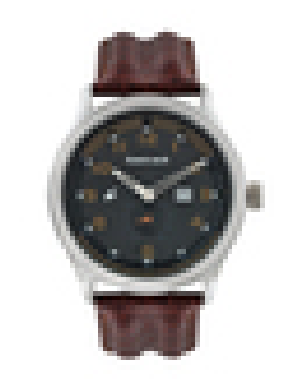

In [75]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "/content/fashion-product-images-small/images"

sample = os.listdir(image_dir)[70]
img = Image.open(os.path.join(image_dir, sample))
plt.imshow(img)
plt.axis("off")
plt.show()

In [76]:
#telling python wich all images are there

# create correct image path for each row using image id
data["image_path"] = data["id"].astype(str).apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)

# keep only rows where image actually exists
data = data[data["image_path"].apply(os.path.exists)]

# check result
print("Total usable images:", len(data))
print(data["category"].value_counts())

data[["id", "articleType", "category", "image_path"]].head()

Total usable images: 21395
category
tops           13887
accessories     2899
footwears       2460
bottoms         1685
dresses          464
Name: count, dtype: int64


,id,articleType,category,image_path
0,15970,Shirts,tops,/content/fashion-product-images-small/images/1...
1,39386,Jeans,bottoms,/content/fashion-product-images-small/images/3...
4,53759,Tshirts,tops,/content/fashion-product-images-small/images/5...
5,1855,Tshirts,tops,/content/fashion-product-images-small/images/1...
6,30805,Shirts,tops,/content/fashion-product-images-small/images/3...


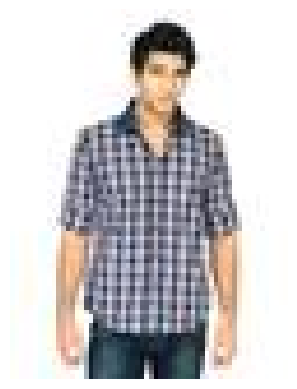

Article Type: Shirts
Category: tops


In [77]:
from PIL import Image
import matplotlib.pyplot as plt

sample = data.iloc[0]

img = Image.open(sample["image_path"])

plt.imshow(img)
plt.axis("off")
plt.show()

print("Article Type:", sample["articleType"])
print("Category:", sample["category"])

In [120]:
print(img.size)

(60, 80)


(224, 224)


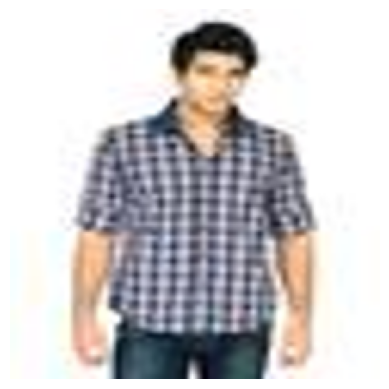

In [121]:
img_resized = img.resize((224, 224))

print(img_resized.size)

plt.imshow(img_resized)
plt.axis("off")
plt.show()

In [123]:
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["category"],
    random_state=42
)

In [125]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["category"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["category"]
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.476153514445882), 1: np.float64(2.53946587537092), 2: np.float64(9.226954177897575), 3: np.float64(1.7394308943089432), 4: np.float64(0.3081188118811881)}


In [126]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

train_ds = train_gen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_ds = test_gen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="category",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 17116 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [127]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [128]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 257s 457ms/step - accuracy: 0.5061 - loss: 1.1822 - val_accuracy: 0.7731 - val_loss: 0.8194
Epoch 2/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 231s 431ms/step - accuracy: 0.6272 - loss: 0.8589 - val_accuracy: 0.8009 - val_loss: 0.7005
Epoch 3/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 234s 437ms/step - accuracy: 0.6510 - loss: 0.7820 - val_accuracy: 0.8334 - val_loss: 0.6492
Epoch 4/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 231s 431ms/step - accuracy: 0.6746 - loss: 0.7401 - val_accuracy: 0.8413 - val_loss: 0.5743
Epoch 5/5
535/535 ━━━━━━━━━━━━━━━━━━━━ 232s 433ms/step - accuracy: 0.6801 - loss: 0.7156 - val_accuracy: 0.8434 - val_loss: 0.6262


In [129]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.8434 - loss: 0.6262
Test Accuracy: 0.8434213399887085


In [130]:
import numpy as np
from sklearn.metrics import classification_report

pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)
y_true = test_ds.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_ds.class_indices.keys())
))

134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step
              precision    recall  f1-score   support

 accessories       0.66      0.78      0.72       580
     bottoms       0.98      0.70      0.82       337
     dresses       0.13      0.28      0.18        93
   footwears       0.74      0.99      0.85       492
        tops       0.96      0.87      0.91      2777

    accuracy                           0.84      4279
   macro avg       0.70      0.72      0.69      4279
weighted avg       0.88      0.84      0.85      4279



In [133]:
model.save("style_buddy_category_classifier-model1.keras")

In [134]:
import os
os.listdir()

['.config',
 'style_buddy_category_classifier-model1.keras',
 'fashion-product-images-small',
 'style_buddy_category_classifier-model1.h5',
 'sample_data']

In [135]:

os.remove("style_buddy_category_classifier-model1.h5")

In [136]:
os.listdir()

['.config',
 'style_buddy_category_classifier-model1.keras',
 'fashion-product-images-small',
 'sample_data']